In [1]:
import jax
import jax.numpy as jnp
import numpy as np

In [2]:
import mpmath

In [3]:
import jaxpolylog

In [4]:
t = 2*1j
t = 1*1j
t = .00001*1j#+.1
z = np.exp(2*np.pi*1j*t)
Li3_series = jaxpolylog.jax_polylog(z,3,100,approx="inf")
Li3_int = jaxpolylog.jax_polylog(z,3,10**5,approx="integral")
Li3_zero = jaxpolylog.jax_polylog(z,3,10**2,approx="zero")
Li3_patch = jaxpolylog.jax_polylog(z,3,10**2,approx="patch")
Li3_mpm = mpmath.polylog(3,z)
Li3_series,Li3_int,Li3_zero,Li3_patch,Li3_mpm

(Array(1.20190369+0.j, dtype=complex128),
 Array(1.20680802+0.j, dtype=complex128),
 Array(1.20195357+1.26572458e-20j, dtype=complex128),
 Array(1.20195357+1.26572458e-20j, dtype=complex128),
 mpc(real='1.2019535709626754', imag='0.0'))

In [5]:
t = 2*1j
t = 0.2*1j
#t = .001*1j#+.1
s = 2
z = np.exp(2*np.pi*1j*t)
Lis_series = jaxpolylog.jax_polylog(z,s,10,approx="inf")
Lis_int = jaxpolylog.jax_polylog(z,s,10**6,approx="integral")
Lis_zero = jaxpolylog.jax_polylog(z,s,10,approx="zero")
Lis_patch = jaxpolylog.jax_polylog(z,s,10**2,approx="patch")
Lis_mpm = mpmath.polylog(s,z)
Lis_series,Lis_int,Lis_zero,Lis_patch,Lis_mpm

(Array(0.30792522+0.j, dtype=complex128),
 Array(0.30792959+0.j, dtype=complex128),
 Array(0.30792527+8.66984361e-17j, dtype=complex128),
 Array(0.30792527+8.66984359e-17j, dtype=complex128),
 mpc(real='0.30792526608925103', imag='0.0'))

In [6]:
t = 2*1j
#t = 1*1j
t = .001*1j#+.1
s = 1
z = np.exp(2*np.pi*1j*t)
Lis_series = jaxpolylog.jax_polylog(z,s,10,approx="inf")
Lis_int = jaxpolylog.jax_polylog(z,s,10**6,approx="integral")
Lis_zero = jaxpolylog.jax_polylog(z,s,10,approx="zero")
Lis_mpm = mpmath.polylog(s,z)
Lis_series,Lis_int,Lis_zero,Lis_mpm

(Array(5.07301816-0.j, dtype=complex128),
 Array(5.07301816-0.j, dtype=complex128),
 Array(5.07301816-0.j, dtype=complex128),
 mpc(real='5.0730181602928583', imag='0.0'))

In [7]:
p_range = 10
mu = jnp.log(z)
Hs = jnp.sum(1/jnp.arange(1,s))
term1 = (mu)**(s-1)/jax.scipy.special.gamma(s)*(Hs-jnp.log(-mu))

# Values of zeta function from s to 2
zeta_pos = jax.scipy.special.zeta(s-jnp.arange(0,s-1),q=1)
zeta = jnp.append(zeta_pos,jnp.zeros(1))

# Values of zeta function from 0 to -p_range
Bs = jax.scipy.special.bernoulli(p_range)[1:]
Bs = Bs.at[0].set(0.5)
zneg_range = jnp.arange(1,p_range+1)
zeta_neg = -Bs/zneg_range

zeta = jnp.append(zeta,zeta_neg)
zeta = zeta.at[s-1].set(0.)
polylog_range = jnp.arange(0,zeta.shape[0])
coeffs = zeta/jax.scipy.special.factorial(polylog_range)

term2 = jnp.sum(coeffs*mu**polylog_range)
term1 + term2

Array(5.07301816-3.84331246e-19j, dtype=complex128)

In [90]:
jnp.arange(0,zeta.shape[0])

Array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11], dtype=int64)

In [83]:
def polylog_patched(z,s,p_range=10,pval = 0.2):

    mu = jnp.log(z)
    t = jnp.abs(mu)/2/jnp.pi

    #t = jnp.abs(mu.real)/2/jnp.pi
    
    Lis_inf = jaxpolylog.jax_polylog(z,s,p_range,approx="inf")
    Lis_zero = jaxpolylog.jax_polylog(z,s,p_range,approx="zero")
    h1 = jnp.heaviside(pval-t,1.)
    h2 = jnp.heaviside(t-pval,0.)

    return Lis_inf*h2+h1*Lis_zero

In [84]:
prange = 100
s = 3

t = 2*1j
t = 1*1j
t = .1*1j#+.1
t = .1*1j+.3

z = np.exp(2*np.pi*1j*t)
Lis_series = jaxpolylog.jax_polylog(z,s,prange,approx="inf")
Lis_zero = jaxpolylog.jax_polylog(z,s,prange,approx="zero")
Lis_patch = polylog_patched(z,s,p_range=prange)
Lis_mpm = mpmath.polylog(s,z)
print("Li jax inf: ",Lis_series)
print("Li jax zero: ",Lis_zero)
print("Li jax patch: ",Lis_patch)
print("Li mpmath: ",Lis_mpm)

Li jax inf:  (-0.18899205433564387+0.48428747968087743j)
Li jax zero:  (-0.1889920549720505+0.48428748137311084j)
Li jax patch:  (-0.18899205433564387+0.48428747968087743j)
Li mpmath:  (-0.188992054335644 + 0.484287479680877j)


In [81]:
jnp.log(z)/2/jnp.pi

Array(-0.1+0.3j, dtype=complex128)

In [22]:
N = 10**4
X = np.linspace(1,N*10**4,N)/N/10**2
t = X*1j#+np.random.uniform(-0.5,0.5,N)
z = np.exp(2*np.pi*1j*t)

In [23]:
from tqdm.auto import tqdm
s = 2
Lis_series = jaxpolylog.jax_polylog_vmap(z,s,10,approx="inf")
Lis_int = jaxpolylog.jax_polylog_vmap(z,s,10,approx="integral")
Lis_zero = jaxpolylog.jax_polylog_vmap(z,s,10,approx="zero")
Lis_mpm = []
for z0 in tqdm(z):
    Lis_mpm.append(float(mpmath.polylog(s,z0).real))

  0%|          | 0/10000 [00:00<?, ?it/s]

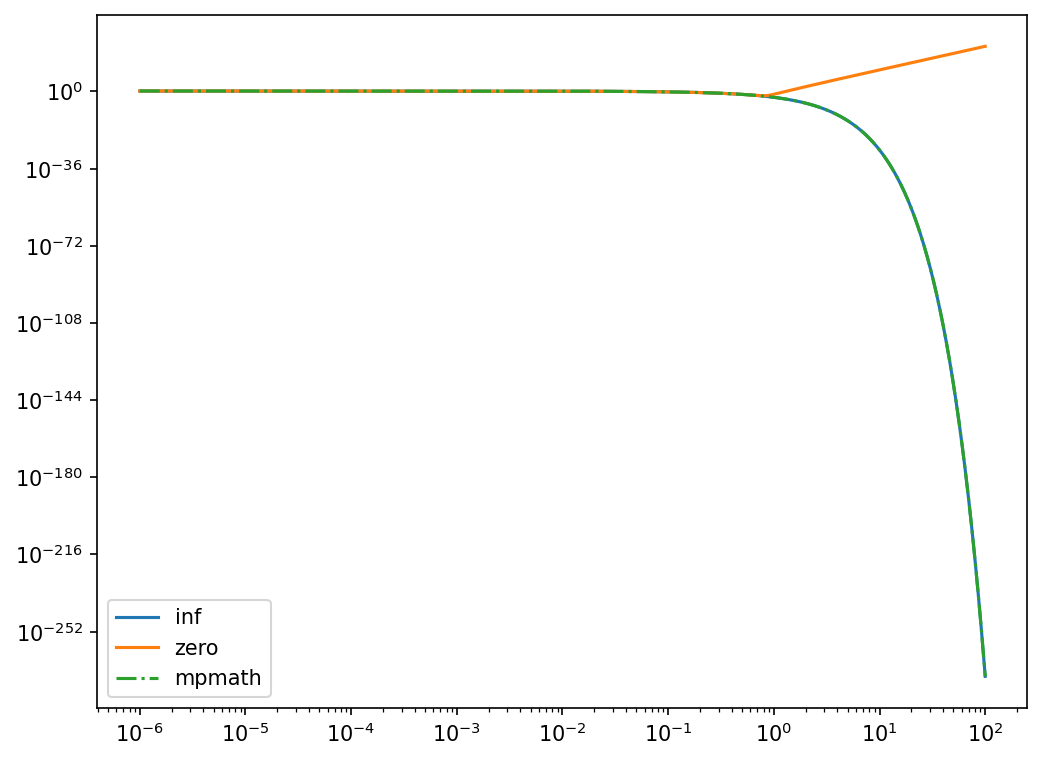

In [24]:
import matplotlib.pyplot as plt
import seaborn as sn
fig = plt.figure(dpi=150,figsize=(8,6))
sn.lineplot(x=X,y=Lis_series.real,label="inf")
#sn.lineplot(x=X,y=Lis_int.real,label="integral")
sn.lineplot(x=X,y=Lis_zero.real,label="zero")
sn.lineplot(x=X,y=np.array(Lis_mpm).real,label="mpmath",ls="-.")
plt.xscale("log")
plt.yscale("log")
plt.show()

In [1]:
# Important standard libraries
import os, sys, warnings
from functools import partial

# Important JAX libraries
import jax
from jax import custom_vjp
from jax import jit, vmap, config
import jax.numpy as jnp
from jax import Array
from numpy.typing import ArrayLike

# Enable 64 bit precision
config.update("jax_enable_x64", True)


def _compute_pval_optimal() -> float:
    r"""
    Find the optimal transition parameter ``t*`` for the ``"patch"`` method.

    The ``"patch"`` method switches between two series expansions of Li_s(z):

    * **"inf"** series: ``Li_s(z) = Σ z^k / k^s``, convergent for ``|z| < 1``.
      After ``N`` terms the truncation error scales as ``|z|^N``.
    * **"zero"** expansion: Laurent series in ``μ = log z`` around ``μ = 0``
      (``z = 1``), convergent for ``|μ| < 2π``.  After ``N`` terms the error
      scales as ``(|μ|/(2π))^N = t^N`` where ``t = |μ|/(2π)``.

    For real positive ``z < 1`` both errors are equal when

    .. math::
        |z|^N = t^N \;\Longrightarrow\; |z| = t \;\Longrightarrow\;
        e^{-|μ|} = \frac{|μ|}{2π} \;\Longrightarrow\; e^{-2πt} = t \,.

    The unique positive solution of ``e^{-2πt} = t`` is computed here by
    bisection and stored as the module constant :data:`_PVAL_OPTIMAL` ≈ 0.2322.
    This fixed point is independent of ``N`` (the ``p_range`` parameter), so
    the optimal crossover does not change with the number of series terms.

    Returns:
        float: Optimal transition parameter ``t*`` ≈ 0.2322.
    """
    import numpy as _np
    # Bisect on f(t) = e^{-2πt} - t.  f(0.05) > 0, f(0.50) < 0.
    lo, hi = 0.05, 0.50
    for _ in range(80):           # 80 iterations → sub-ULP accuracy
        mid = 0.5 * (lo + hi)
        if _np.exp(-2.0 * _np.pi * mid) > mid:
            lo = mid
        else:
            hi = mid
    return 0.5 * (lo + hi)


# Optimal patch transition: t* = |log z| / (2π) at which the truncation errors
# of the "inf" series and the "zero" expansion are equal.  Precomputed once at
# import time by solving e^{-2πt} = t via bisection (~0.2322).
_PVAL_OPTIMAL: float = _compute_pval_optimal()
_PVAL_OPTIMAL

0.23231338255518164

In [31]:
import numpy as np
from jaxpolylog import jax_polylog
t = .23*1j+.1
z = np.exp(2*np.pi*1j*t)
s=2
p_range=10
pval = _PVAL_OPTIMAL

In [32]:
# t = |log z| / (2π): normalised distance from the nearest root of
# unity in log-space.  The "zero" expansion converges for t < 1 and
# the "inf" series converges for |z| < 1.
mu = jnp.log(z)
t  = jnp.abs(mu) / (2.0 * jnp.pi)

Lis_inf  = jax_polylog(z, s, p_range, "inf",  pval)
Lis_zero = jax_polylog(z, s, p_range, "zero", pval)

# Use "inf" only when BOTH conditions hold:
#   (a) |z| < 1  — the "inf" series converges; it diverges for |z| ≥ 1
#   (b) t ≥ pval — the "inf" series has smaller truncation error
# Everything else (including all points on or outside the unit circle)
# falls back to the "zero" expansion.
inside_disk = jnp.heaviside(1.0 - jnp.abs(z), 0.0)   # 1 if |z| < 1
prefer_inf  = jnp.heaviside(t - pval, 0.0)            # 1 if t ≥ pval
w_inf  = inside_disk * prefer_inf
w_zero = 1.0 - w_inf
print(w_inf,w_zero)
Lis_inf * w_inf + Lis_zero * w_zero

1.0 0.0


Array(0.19435073+0.15325385j, dtype=complex128)

In [33]:
import mpmath
Lis_mpm = mpmath.polylog(s,z)
print("Li mpmath: ",Lis_mpm)

Li mpmath:  (0.194350737947342 + 0.153253845906308j)
